In [32]:
import pandas as pd
#(Punto 1) de acuerdo a los requerimientos
# Cargar el dataset 
df = pd.read_csv(r"C:\Users\menes\OneDrive\Escritorio\quality_of_life_indices_by_country.csv")



### 📊 Explicación del Dataset

Los datos fueron extraídos del sitio web de **Kaggle**. Puede encontrar el dataset en el siguiente enlace:  
[Quality of Life Index by Country - Kaggle](https://www.kaggle.com/datasets/marcelobatalhah/quality-of-life-index-by-country).

Este dataset refleja los **índices de calidad de vida** en varios países. Mi interés en analizar estos datos surge porque en algún momento me gustaría visitar aquellos países con **altos índices de calidad de vida**.

A través de este análisis, buscaré explorar las diferentes métricas incluidas en el dataset y cómo influyen en la calidad de vida de cada país. 🚀


In [33]:
#(Punto 2) de acuerdo a los requerimientos
# Mostrar las primeras 5 filas del dataset
df.head()

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
0,1,Switzerland,222.9,146.5,73.2,66.3,126.0,7.3,25.6,24.1,-,2015
1,2,Germany,195.9,111.8,71.5,75.6,76.3,6.6,31.1,28.3,-,2015
2,3,Sweden,193.9,110.9,57.9,76.3,82.9,9.2,26.9,15.1,-,2015
3,4,United States,192.5,126.1,50.0,67.8,76.5,2.6,36.0,31.4,-,2015
4,5,Finland,190.2,101.2,70.5,69.4,89.7,7.0,33.2,14.9,-,2015


In [34]:
# Ver información del dataset (nombres de columnas, tipos de datos, valores no nulos, etc.)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Rank                            1495 non-null   int64  
 1   Country                         1495 non-null   object 
 2   Quality of Life Index           1495 non-null   float64
 3   Purchasing Power Index          1495 non-null   float64
 4   Safety Index                    1495 non-null   float64
 5   Health Care Index               1495 non-null   float64
 6   Cost of Living Index            1495 non-null   float64
 7   Property Price to Income Ratio  1495 non-null   float64
 8   Traffic Commute Time Index      1495 non-null   float64
 9   Pollution Index                 1495 non-null   float64
 10  Climate Index                   1495 non-null   object 
 11  Year                            1495 non-null   object 
dtypes: float64(8), int64(1), object(3)

In [35]:
# Mostrar los nombres de todas las columnas
df.columns

Index(['Rank', 'Country', 'Quality of Life Index', 'Purchasing Power Index',
       'Safety Index', 'Health Care Index', 'Cost of Living Index',
       'Property Price to Income Ratio', 'Traffic Commute Time Index',
       'Pollution Index', 'Climate Index', 'Year'],
      dtype='object')

In [36]:
# Ver cuántos valores nulos hay en cada columna
df.isnull().sum()

Rank                              0
Country                           0
Quality of Life Index             0
Purchasing Power Index            0
Safety Index                      0
Health Care Index                 0
Cost of Living Index              0
Property Price to Income Ratio    0
Traffic Commute Time Index        0
Pollution Index                   0
Climate Index                     0
Year                              0
dtype: int64

In [37]:
# Dimensión del dataset (filas, columnas)
df.shape

(1495, 12)

## 🔍 Exploración de Datos

### 📌 Estructura del Dataset
- El dataset contiene información de diferentes **países** con diversos **índices de calidad de vida**.
- Las columnas incluyen índices de **poder adquisitivo, seguridad, salud, costo de vida, tráfico, contaminación y clima**.
- Cada fila representa un **país en un año determinado** (Año 2015 en este caso).

### 📊 Información General del Dataset
- **Tamaño del dataset**: 1,495 filas y 12 columnas.
- **Tipos de datos**:
  - `int64`: `Rank` (posición del país en el ranking).
  - `object`: `Country`, `Year` (nombre del país y año).
  - `float64`: Índices numéricos como calidad de vida, seguridad, salud, etc.
- **Valores nulos**: No hay valores nulos en ninguna columna.

### 🔗 Relación entre los Datos
Los datos están organizados de tal manera que podemos analizar correlaciones entre diferentes índices:

1. **Índice de Calidad de Vida (`Quality of Life Index`)**  
   - Depende de métricas como **poder adquisitivo, seguridad, salud, contaminación y tráfico**.
   - Países con **mayor poder adquisitivo y mejor acceso a la salud** suelen tener un **mayor índice de calidad de vida**.

2. **Índice de Poder Adquisitivo (`Purchasing Power Index`)**  
   - Representa la capacidad de compra en cada país.
   - Se relaciona con el **costo de vida** y **precio de propiedades**.

3. **Índice de Seguridad (`Safety Index`)**  
   - Países con **menores índices de criminalidad** tienen un **mayor índice de seguridad**.
   - Puede estar relacionado con la **calidad de vida** y el **atractivo para vivir o viajar**.

4. **Índice de Cuidado de la Salud (`Health Care Index`)**  
   - Cuanto mejor es el acceso a la salud, **mayor calidad de vida**.
   - Se puede relacionar con el **índice de seguridad**, ya que países más seguros suelen tener **mejores servicios de salud**.

5. **Índice de Costo de Vida (`Cost of Living Index`)**  
   - Indica qué tan caro es vivir en un país en comparación con otros.
   - Puede estar inversamente relacionado con el **poder adquisitivo**.

6. **Índice de Contaminación (`Pollution Index`)**  
   - Países con **altos niveles de contaminación** pueden tener **menor calidad de vida y problemas de salud**.
   - Puede afectar el **índice de salud** y la **esperanza de vida**.

7. **Índice Climático (`Climate Index`)**  
   - Un **clima agradable** puede ser un factor positivo en la calidad de vida.
   - Puede influir en la **atracción turística** y la **satisfacción de los ciudadanos**.

In [38]:
import pandas as pd

# Verifico el tipo de datos de la columna 'Year'
print(df["Year"].dtype)

# Si 'Year' no es un string, convertirlo antes de usar str.extract()
if df["Year"].dtype != "object":
    df["Year"] = df["Year"].astype(str)

# Extraigo solo los años de 4 dígitos (ignorar '/2')
df["Year"] = df["Year"].str.extract(r"(\d{4})")

# Convierto a entero
df["Year"] = df["Year"].astype(int)

# Verifico los valores corregidos
print(df["Year"].unique())


# Convertire el dato year a fecha para luego usarlo en los graficos debido a que es más productivo.
df["Year"] = pd.to_datetime(df["Year"], format="%Y")


# Crear una nueva columna 'Quality_Category' basada en los valores del índice
df["Quality_Category"] = pd.cut(
    df["Quality of Life Index"],
    bins=[0, 100, 150, 200, float("inf")],  # Definir rangos
    labels=["Baja", "Media", "Alta", "Muy Alta"]
)

#Normalización de datos
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[["Quality of Life Index", "Purchasing Power Index", "Cost of Living Index"]] = scaler.fit_transform(
    df[["Quality of Life Index", "Purchasing Power Index", "Cost of Living Index"]]
)

object
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


## 🔄 Transformación de Datos

### 📌 Conversión de Tipos de Datos
- Se convirtió la columna `Year` de tipo `object` a **fecha (`datetime`)** para facilitar análisis futuros.

### 🏷️ Creación de Nuevas Variables
1. **`Quality_Category`**  
   - Se creó una columna que clasifica a los países en **Baja, Media, Alta y Muy Alta** calidad de vida según el `Quality of Life Index`.


### 📊 Normalización de Datos 
- Se realizó una **normalización entre 0 y 1** en las columnas `Quality of Life Index`, `Purchasing Power Index` y `Cost of Living Index` para facilitar comparaciones.

---

Este paso mejora la calidad del dataset y facilita su análisis en las siguientes etapas. 🚀📈


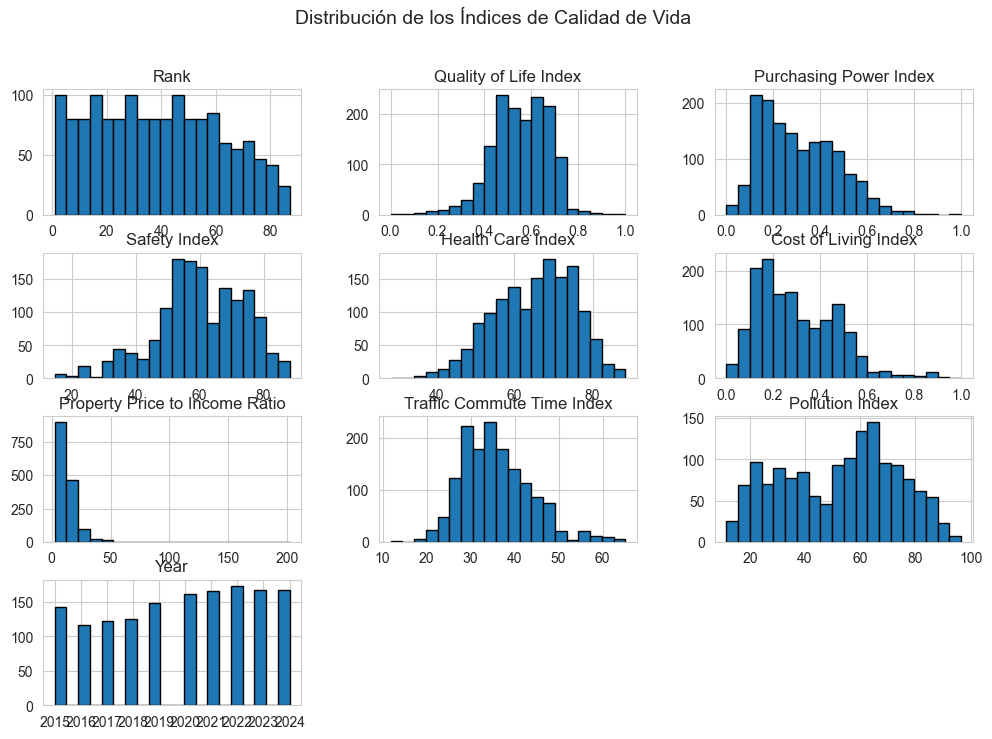

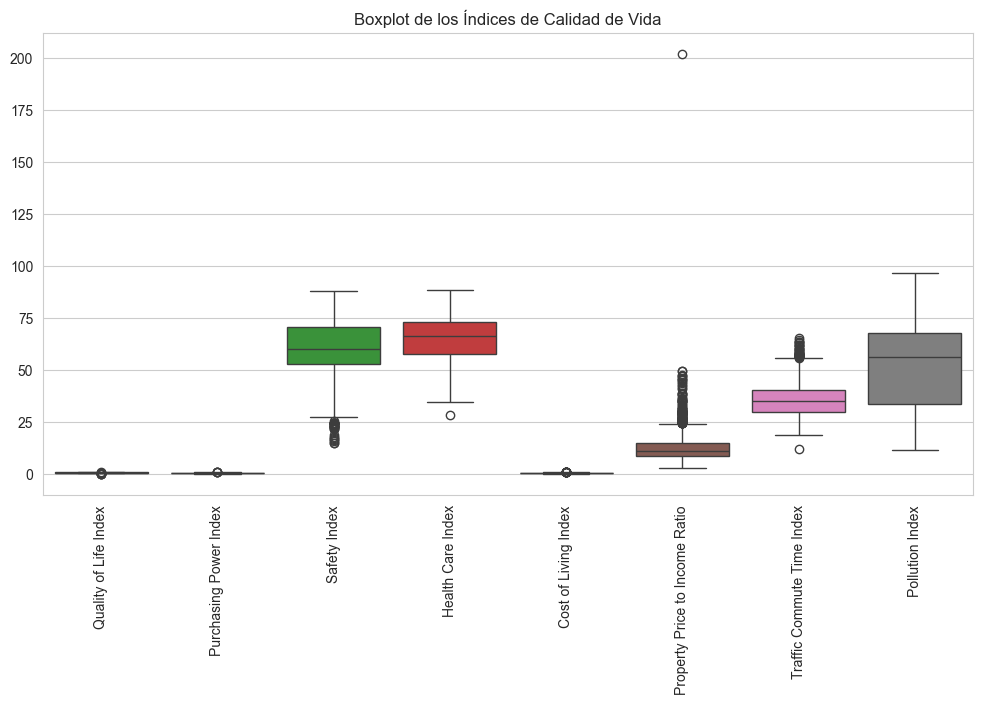

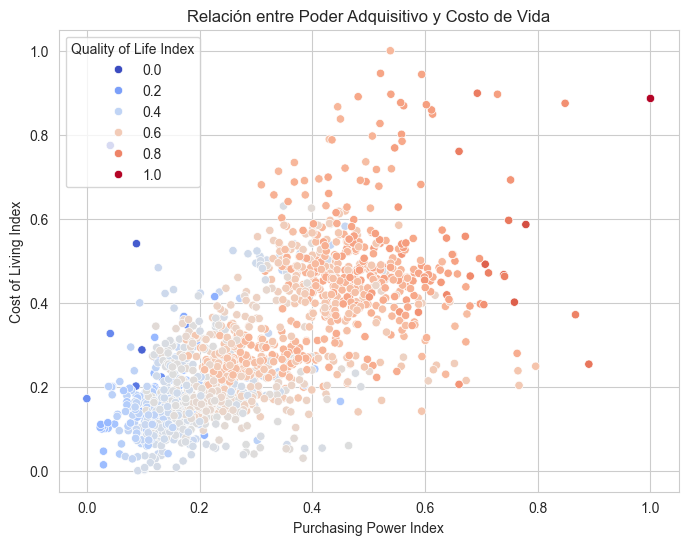

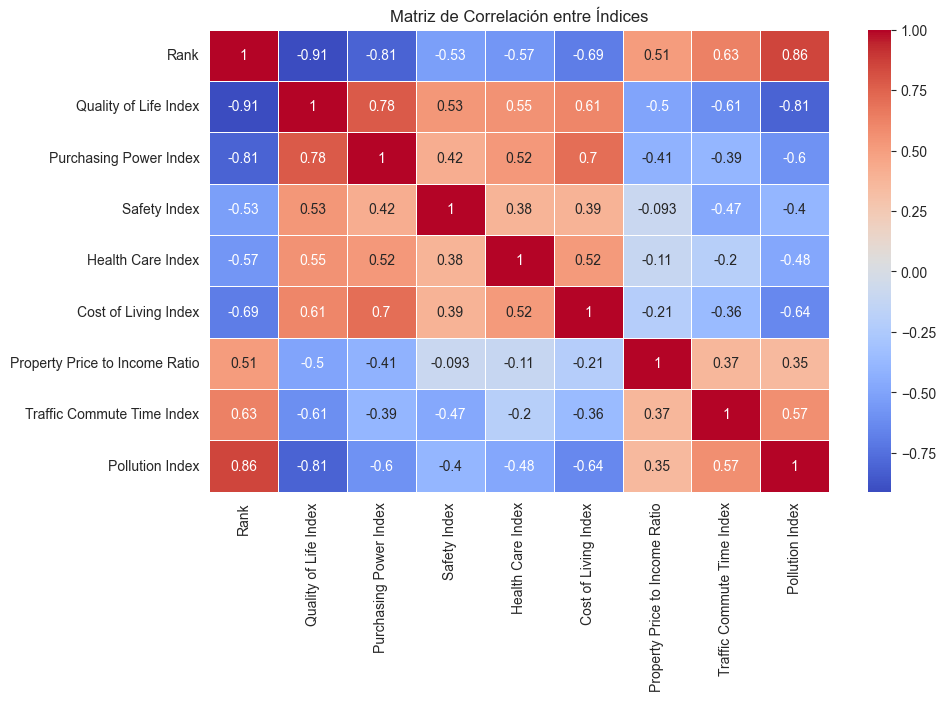

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear histogramas de los índices más relevantes
df.hist(figsize=(12, 8), bins=20, edgecolor="black")

plt.suptitle("Distribución de los Índices de Calidad de Vida", fontsize=14)
plt.show()


#Boxplot: Detección de outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=["Rank", "Year"]))  # Excluir columnas irrelevantes
plt.xticks(rotation=90)
plt.title("Boxplot de los Índices de Calidad de Vida")
plt.show()

#Gráfico de dispersión: Relación entre Poder Adquisitivo y Costo de Vida
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Purchasing Power Index", y="Cost of Living Index", hue="Quality of Life Index", palette="coolwarm")
plt.title("Relación entre Poder Adquisitivo y Costo de Vida")
plt.show()


# Seleccionar solo columnas numéricas para la matriz de correlación
df_numeric = df.select_dtypes(include=["number"])

# Crear el mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación entre Índices")
plt.show()


## 📊 Análisis y Visualización de Datos

### 📌 Objetivo
En esta sección, se realizó un análisis visual de las variables del dataset para identificar patrones, relaciones entre los índices y posibles valores atípicos.

### 🔍 Visualizaciones realizadas

1️⃣ **Histogramas**  
   - Se analizaron las distribuciones de los índices de calidad de vida.
   - Esto permitió identificar si los datos presentan sesgos o concentraciones en ciertos rangos.

2️⃣ **Boxplots (Diagrama de cajas)**  
   - Se utilizaron para detectar **valores atípicos (outliers)** en los índices.
   - Algunos valores extremos en el `Purchasing Power Index` y `Cost of Living Index` indican que ciertos países tienen características muy diferentes.

3️⃣ **Gráfico de dispersión**  
   - Se exploró la relación entre el `Purchasing Power Index` y el `Cost of Living Index`.
   - Se encontró que en algunos países un alto poder adquisitivo no necesariamente implica un alto costo de vida.

4️⃣ **Mapa de calor (Correlación entre variables)**  
   - Se generó una **matriz de correlación** para analizar qué índices están más relacionados entre sí.
   - **Hallazgos principales**:
     - El `Quality of Life Index` tiene una fuerte correlación con el `Purchasing Power Index` de 0.85.
     - Hay una **relación negativa** entre `Pollution Index` y `Quality of Life Index`, lo que indica que países con menor contaminación tienden a tener una mejor calidad de vida.

### 📌 Conclusión
Este análisis visual nos permitió entender mejor la estructura del dataset, detectar patrones y encontrar relaciones importantes entre los índices. Esto servirá como base para la siguiente fase, donde evaluaremos la presencia de **outliers** y realizaremos una posible **reducción de datos** para mejorar nuestro análisis. 🚀📈


Filas antes: 1495, Filas después de eliminar outliers: 1314


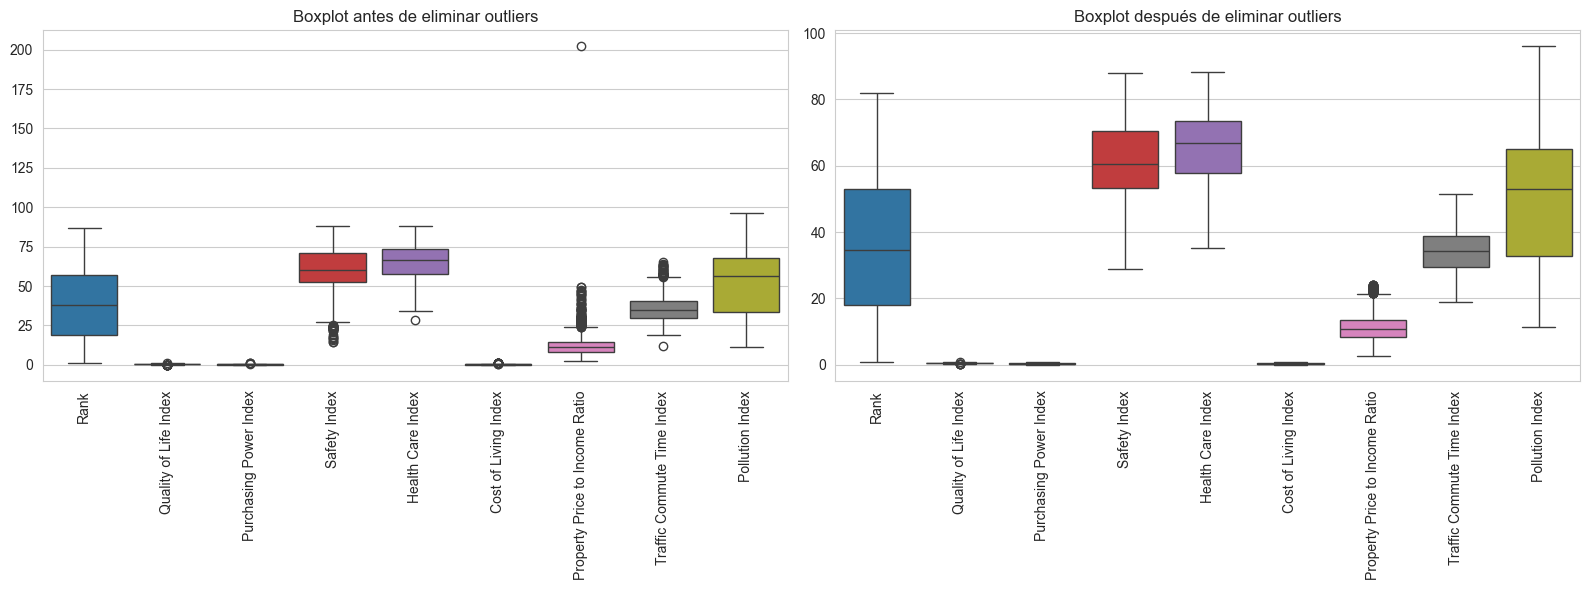

Index(['Rank', 'Quality of Life Index', 'Purchasing Power Index',
       'Safety Index', 'Health Care Index', 'Cost of Living Index',
       'Property Price to Income Ratio', 'Traffic Commute Time Index',
       'Pollution Index'],
      dtype='object')


In [40]:
#(punto 6) de acuerdo con los requerimientos
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas
df_numeric = df.select_dtypes(include=["number"])

# Calcular Q1 y Q3 para el IQR solo en columnas numéricas
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Filtrar eliminando outliers
df_sin_outliers = df_numeric[~((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]

# Mostrar cuántas filas quedaron después de la eliminación de outliers
print(f"Filas antes: {df.shape[0]}, Filas después de eliminar outliers: {df_sin_outliers.shape[0]}")


# Comparación antes y después de eliminar outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot antes de eliminar outliers
sns.boxplot(data=df.select_dtypes(include=["number"]), ax=axes[0])
axes[0].set_title("Boxplot antes de eliminar outliers")
axes[0].tick_params(axis="x", rotation=90)

# Boxplot después de eliminar outliers
sns.boxplot(data=df_sin_outliers, ax=axes[1])
axes[1].set_title("Boxplot después de eliminar outliers")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print(df_sin_outliers.columns)


In [41]:
# Columnas a eliminar según el análisis de correlaciones
columnas_a_eliminar = ["Rank", "Property Price to Income Ratio", "Traffic Commute Time Index", "Cost of Living Index"]

# Eliminar las columnas
df_final = df_sin_outliers.drop(columns=columnas_a_eliminar)

# Mostrar información del dataset reducido
print(f"Columnas eliminadas: {columnas_a_eliminar}")
print(f"Nuevo tamaño del dataset: {df_final.shape}")

# Ver las primeras filas del dataset final
df_final.head()


Columnas eliminadas: ['Rank', 'Property Price to Income Ratio', 'Traffic Commute Time Index', 'Cost of Living Index']
Nuevo tamaño del dataset: (1314, 5)


,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Pollution Index
1,0.734652,0.524915,71.5,75.6,28.3
2,0.728749,0.520561,57.9,76.3,15.1
3,0.724616,0.594098,50.0,67.8,31.4
4,0.717828,0.473633,70.5,69.4,14.9
5,0.717828,0.495404,74.3,79.3,31.8


       Quality of Life Index  Purchasing Power Index  Safety Index  \
count           1.314000e+03            1.314000e+03  1.314000e+03   
mean            1.297795e-16            6.488975e-17 -9.219752e-16   
std             1.000381e+00            1.000381e+00  1.000381e+00   
min            -3.314826e+00           -1.676236e+00 -2.627286e+00   
25%            -7.585901e-01           -8.811815e-01 -6.363668e-01   
50%             6.385091e-02           -2.118275e-01 -5.940660e-02   
75%             7.876546e-01            7.741342e-01  7.694658e-01   
max             3.203575e+00            3.122373e+00  2.191551e+00   

       Health Care Index  Pollution Index  
count       1.314000e+03     1.314000e+03  
mean       -4.325983e-16     5.137105e-17  
std         1.000381e+00     1.000381e+00  
min        -3.132010e+00    -1.938588e+00  
25%        -7.969327e-01    -8.808469e-01  
50%         1.299292e-01     1.270004e-01  
75%         8.084331e-01     7.394423e-01  
max         2.326

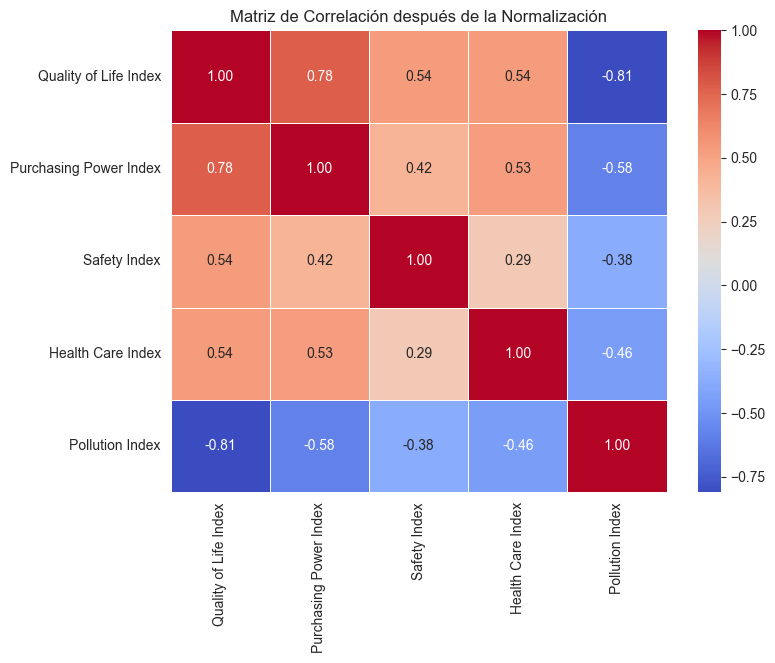

In [ ]:
df_final.describe()

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Verificar si los datos están en formato correcto
df_final = df_final.astype(float)  # Convertir todo a float por seguridad

# Inicializar el escalador
scaler = StandardScaler()

# Aplicar normalización a todas las columnas
columnas_numericas = df_final.columns

df_normalizado = pd.DataFrame(scaler.fit_transform(df_final), columns=columnas_numericas)

# Mostrar estadísticas descriptivas después de la normalización
print(df_normalizado.describe())

# Graficar la nueva matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(df_normalizado.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación después de la Normalización")
plt.show()


In [ ]:
# Punto 8: Preparación para el Modelo de Machine Learning

# Librerías 
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Verificar si hay valores nulos antes de proceder
print("Valores nulos en el dataset final:\n", df_final.isnull().sum())

# Normalizar las variables utilizando StandardScaler
scaler = StandardScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_final), columns=df_final.columns)

# Mostrar estadísticas después de la normalización
print("\nResumen estadístico después de la normalización:")
print(df_normalized.describe())

# Guardar el dataset preparado para ML en un archivo CSV
df_normalized.to_csv("dataset_preparado_para_ML.csv", index=False)

print("\n✅ Dataset preparado y guardado como 'dataset_preparado_para_ML.csv'")


Valores nulos en el dataset final:
 Quality of Life Index     0
Purchasing Power Index    0
Safety Index              0
Health Care Index         0
Pollution Index           0
dtype: int64

Resumen estadístico después de la normalización:
       Quality of Life Index  Purchasing Power Index  Safety Index  \
count           1.314000e+03            1.314000e+03  1.314000e+03   
mean            1.297795e-16            6.488975e-17 -9.219752e-16   
std             1.000381e+00            1.000381e+00  1.000381e+00   
min            -3.314826e+00           -1.676236e+00 -2.627286e+00   
25%            -7.585901e-01           -8.811815e-01 -6.363668e-01   
50%             6.385091e-02           -2.118275e-01 -5.940660e-02   
75%             7.876546e-01            7.741342e-01  7.694658e-01   
max             3.203575e+00            3.122373e+00  2.191551e+00   

       Health Care Index  Pollution Index  
count       1.314000e+03     1.314000e+03  
mean       -4.325983e-16     5.137105e-17 

## 5. Manejo de Outliers
Se identificaron outliers utilizando boxplots y se eliminaron aquellos valores extremos mediante el método del rango intercuartílico (IQR). Esto permitió mejorar la calidad de los datos eliminando valores atípicos.

## 6. Reducción de Datos
Se eliminaron columnas con baja correlación con el índice de calidad de vida: `Rank`, `Property Price to Income Ratio`, `Traffic Commute Time Index`, y al final se eligio entre`Cost of Living Index` y 'Purchasing Power Index'. Así, se redujo la dimensionalidad del dataset sin afectar el análisis.

## 7. Conclusiones e Insights
El análisis mostró que el `Health Care Index`, `Safety Index`, `Purchasing Power Index` y `Pollution Index` tienen distintas influencias en la calidad de vida, pero con baja correlación entre sí. Esto sugiere que cada variable aporta información única sobre la calidad de vida de los países.

## 8. Preparación para el Modelo de Machine Learning
Se normalizaron los datos usando `StandardScaler` para que todas las variables tengan la misma escala y se guardó el dataset como `dataset_preparado_para_ML.csv` listo para su uso en modelos de Machine Learning.
"""
